# 00d V2 Data EDA and Seasonality Validation

Purpose:
- Validate realism before modeling
- Check trend, seasonality, volatility, and operational feature behavior
- Check FG↔RM lead-lag relationship


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

ROOT = Path('/Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/modeling')
GEN = ROOT / 'outputs' / 'generated'
REP = ROOT / 'outputs' / 'reports'

P_PATH = GEN / 'p_v2_portable_monthly.csv'
W_PATH = GEN / 'w_v2_wms_monthly.csv'
RM_PATH = GEN / 'p_v2_rm_monthly.csv'

for p in [P_PATH, W_PATH, RM_PATH]:
    assert p.exists(), f'Missing required file: {p}'

p = pd.read_csv(P_PATH)
w = pd.read_csv(W_PATH)
rm = pd.read_csv(RM_PATH)

for df in [p, w, rm]:
    df['month'] = pd.to_datetime(df['month'])

print('P shape:', p.shape, 'W shape:', w.shape, 'RM shape:', rm.shape)

P shape: (4608, 5) W shape: (4608, 15) RM shape: (3510, 5)


In [2]:
def quick_profile(df, code_col='fg_code'):
    return {
        'rows': len(df),
        'n_series': int(df[code_col].nunique()),
        'n_months': int(df['month'].nunique()),
        'month_min': str(df['month'].min().date()),
        'month_max': str(df['month'].max().date()),
        'mean_demand': float(df['demand_units'].mean()),
        'std_demand': float(df['demand_units'].std()),
        'zero_rate': float((df['demand_units'] <= 0).mean()),
    }

profiles = pd.DataFrame([
    {'dataset': 'P_v2', **quick_profile(p)},
    {'dataset': 'W_v2', **quick_profile(w)},
    {'dataset': 'RM_v2', **quick_profile(rm)},
])
profiles

,dataset,rows,n_series,n_months,month_min,month_max,mean_demand,std_demand,zero_rate
0,P_v2,4608,96,48,2022-01-01,2025-12-01,1733.309679,782.722907,0.0
1,W_v2,4608,96,48,2022-01-01,2025-12-01,1733.309679,782.722907,0.0
2,RM_v2,3510,78,45,2021-11-01,2025-10-01,2303.731054,2287.568945,0.0


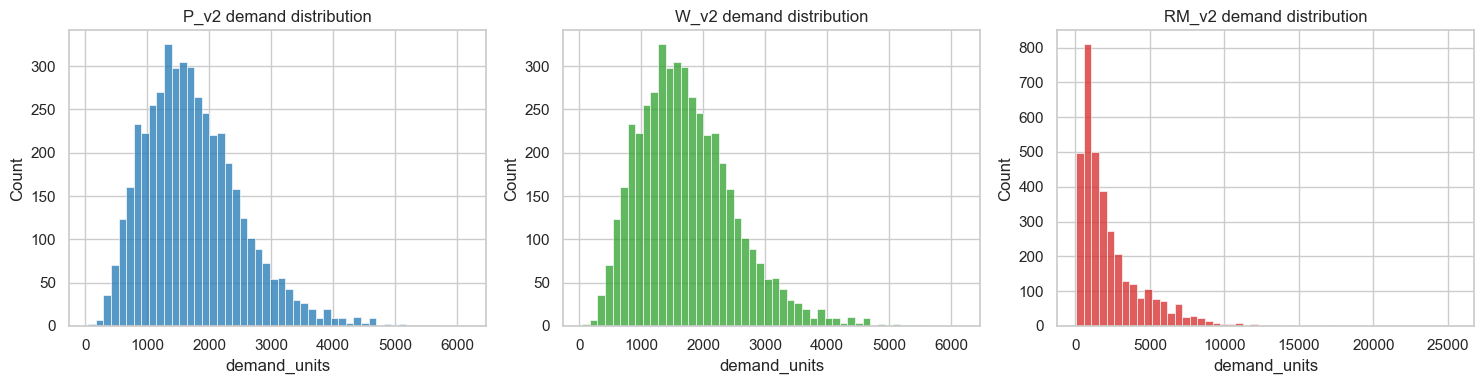

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(p['demand_units'], bins=50, ax=axes[0], color='#1f77b4')
axes[0].set_title('P_v2 demand distribution')

sns.histplot(w['demand_units'], bins=50, ax=axes[1], color='#2ca02c')
axes[1].set_title('W_v2 demand distribution')

sns.histplot(rm['demand_units'], bins=50, ax=axes[2], color='#d62728')
axes[2].set_title('RM_v2 demand distribution')

plt.tight_layout()
plt.show()

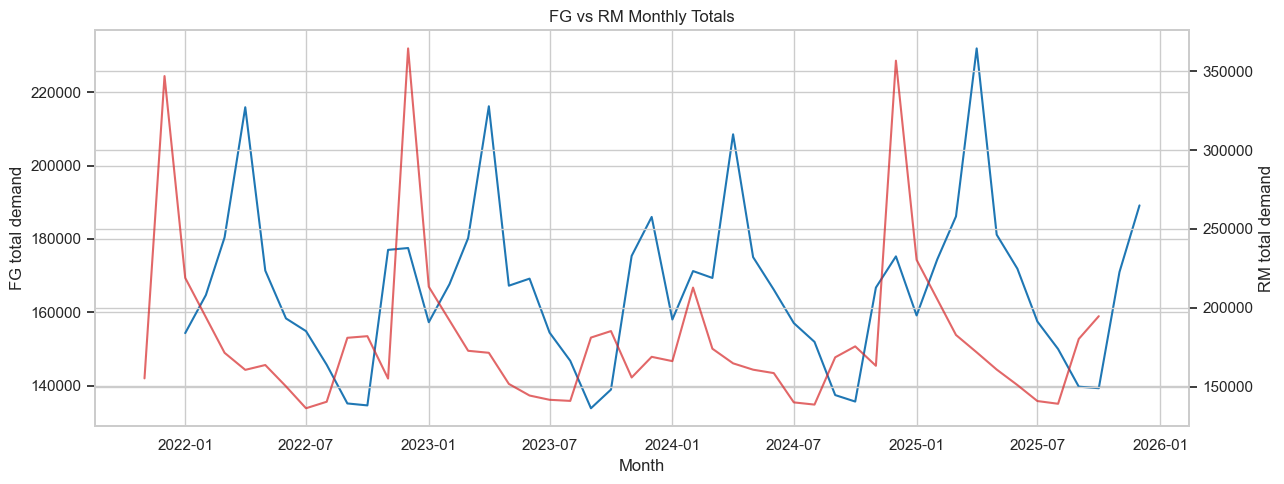

In [4]:
fg_monthly = p.groupby('month', as_index=False)['demand_units'].sum().rename(columns={'demand_units': 'fg_total'})
rm_monthly = rm.groupby('month', as_index=False)['demand_units'].sum().rename(columns={'demand_units': 'rm_total'})

fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.plot(fg_monthly['month'], fg_monthly['fg_total'], label='FG total', color='#1f77b4')
ax1.set_ylabel('FG total demand')

ax2 = ax1.twinx()
ax2.plot(rm_monthly['month'], rm_monthly['rm_total'], label='RM total', color='#d62728', alpha=0.7)
ax2.set_ylabel('RM total demand')

ax1.set_title('FG vs RM Monthly Totals')
ax1.set_xlabel('Month')
fig.tight_layout()
plt.show()

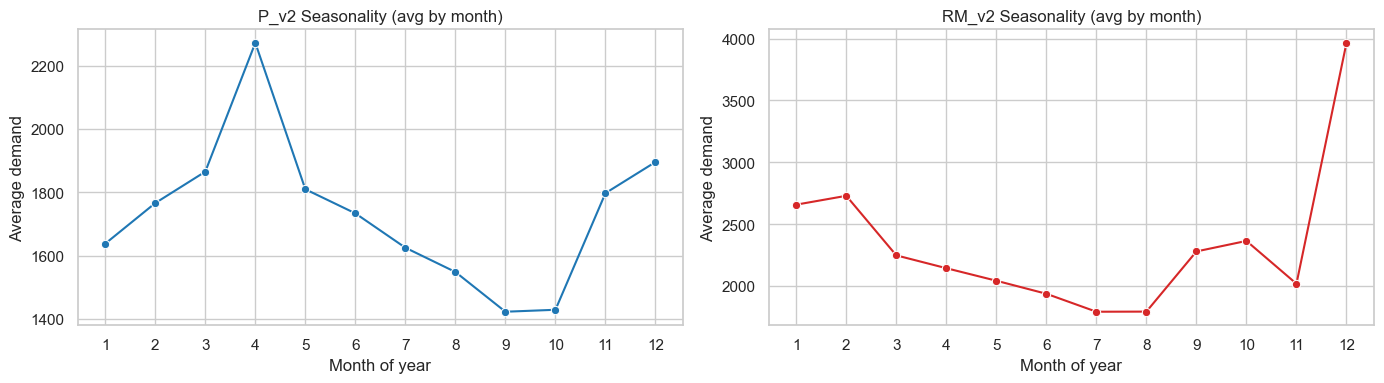

In [5]:
p['month_num'] = p['month'].dt.month
rm['month_num'] = rm['month'].dt.month

p_season = p.groupby('month_num', as_index=False)['demand_units'].mean()
rm_season = rm.groupby('month_num', as_index=False)['demand_units'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)
sns.lineplot(data=p_season, x='month_num', y='demand_units', marker='o', ax=axes[0], color='#1f77b4')
axes[0].set_title('P_v2 Seasonality (avg by month)')

sns.lineplot(data=rm_season, x='month_num', y='demand_units', marker='o', ax=axes[1], color='#d62728')
axes[1].set_title('RM_v2 Seasonality (avg by month)')

for ax in axes:
    ax.set_xticks(range(1, 13))
    ax.set_xlabel('Month of year')
    ax.set_ylabel('Average demand')

plt.tight_layout()
plt.show()

In [6]:
def lag12_strength(df):
    vals = []
    for _, g in df.groupby('fg_code'):
        s = g.sort_values('month')['demand_units'].to_numpy(dtype=float)
        if len(s) < 24:
            continue
        c = np.corrcoef(s[12:], s[:-12])[0, 1]
        if np.isfinite(c):
            vals.append(c)
    return float(np.mean(vals)) if vals else np.nan

season_strength = pd.DataFrame([
    {'dataset': 'P_v2', 'lag12_corr_mean': lag12_strength(p)},
    {'dataset': 'RM_v2', 'lag12_corr_mean': lag12_strength(rm)},
])
season_strength

,dataset,lag12_corr_mean
0,P_v2,0.186448
1,RM_v2,0.070724


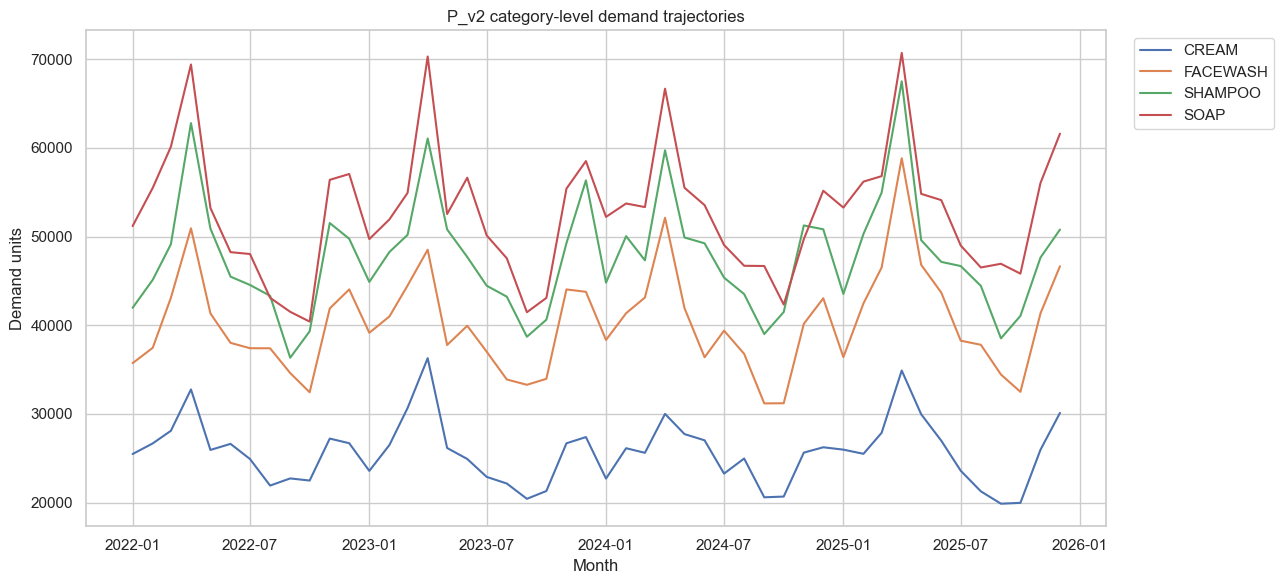

In [7]:
cat_month = p.groupby(['fg_category', 'month'], as_index=False)['demand_units'].sum()
plt.figure(figsize=(13, 6))
sns.lineplot(data=cat_month, x='month', y='demand_units', hue='fg_category')
plt.title('P_v2 category-level demand trajectories')
plt.xlabel('Month')
plt.ylabel('Demand units')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

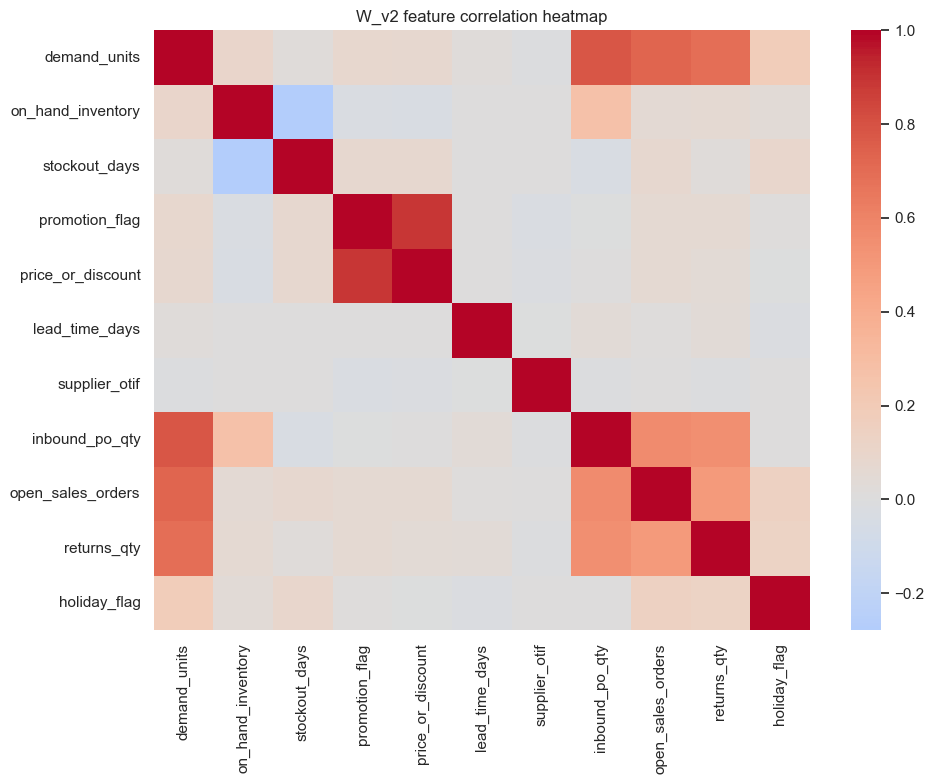

In [8]:
feature_cols = [
    'demand_units', 'on_hand_inventory', 'stockout_days', 'promotion_flag',
    'price_or_discount', 'lead_time_days', 'supplier_otif', 'inbound_po_qty',
    'open_sales_orders', 'returns_qty', 'holiday_flag'
]
corr = w[feature_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('W_v2 feature correlation heatmap')
plt.tight_layout()
plt.show()

In [9]:
promo_effect = (
    w.groupby('promotion_flag', as_index=False)['demand_units']
    .mean()
    .rename(columns={'demand_units': 'avg_demand'})
)
stockout_effect = (
    w.assign(stockout_bin=np.where(w['stockout_days'] > 0, 'stockout>0', 'stockout=0'))
    .groupby('stockout_bin', as_index=False)['demand_units']
    .mean()
    .rename(columns={'demand_units': 'avg_demand'})
)

display(promo_effect)
display(stockout_effect)

,promotion_flag,avg_demand
0,0,1708.057214
1,1,1905.954082


,stockout_bin,avg_demand
0,stockout=0,1719.806202
1,stockout>0,1849.439583


In [10]:
fg_tot = p.groupby('month', as_index=False)['demand_units'].sum().rename(columns={'demand_units': 'fg_total'})
rm_tot = rm.groupby('month', as_index=False)['demand_units'].sum().rename(columns={'demand_units': 'rm_total'})
j = fg_tot.merge(rm_tot, on='month', how='inner').sort_values('month')

rows = []
for lag in range(-6, 7):
    if lag < 0:
        a = j['fg_total'].iloc[:lag].to_numpy(dtype=float)
        b = j['rm_total'].iloc[-lag:].to_numpy(dtype=float)
    elif lag > 0:
        a = j['fg_total'].iloc[lag:].to_numpy(dtype=float)
        b = j['rm_total'].iloc[:-lag].to_numpy(dtype=float)
    else:
        a = j['fg_total'].to_numpy(dtype=float)
        b = j['rm_total'].to_numpy(dtype=float)
    corr = np.corrcoef(a, b)[0, 1] if len(a) > 6 else np.nan
    rows.append({'lag_months_fg_minus_rm': lag, 'corr': corr})

lag_df = pd.DataFrame(rows).sort_values('lag_months_fg_minus_rm')
best = lag_df.loc[lag_df['corr'].idxmax()]
lag_df

,lag_months_fg_minus_rm,corr
0,-6,0.005383
1,-5,-0.171286
2,-4,-0.430711
3,-3,-0.514231
4,-2,-0.374652
5,-1,-0.001980
6,0,0.064891
7,1,0.137172
8,2,0.609560
9,3,0.714442


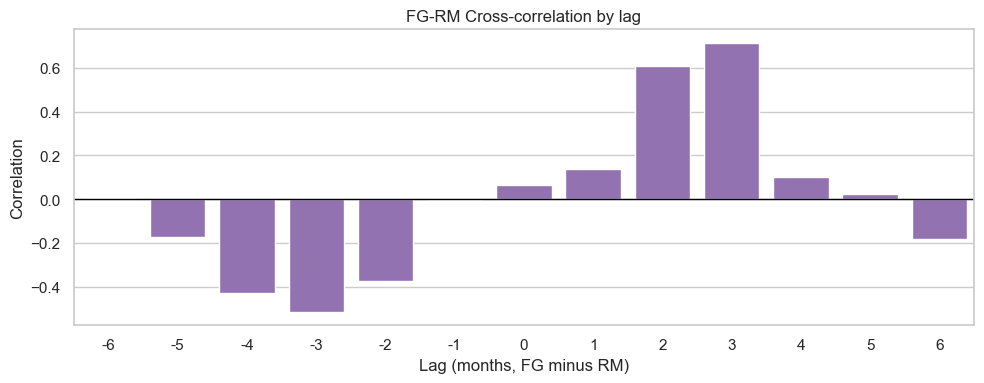

Best lag: 3 corr= 0.7144


In [11]:
plt.figure(figsize=(10, 4))
sns.barplot(data=lag_df, x='lag_months_fg_minus_rm', y='corr', color='#9467bd')
plt.axhline(0, color='black', linewidth=1)
plt.title('FG-RM Cross-correlation by lag')
plt.xlabel('Lag (months, FG minus RM)')
plt.ylabel('Correlation')
plt.tight_layout()
plt.show()

print('Best lag:', int(best['lag_months_fg_minus_rm']), 'corr=', round(float(best['corr']), 4))

In [12]:
eda_summary = {
    'p_shape': list(p.shape),
    'w_shape': list(w.shape),
    'rm_shape': list(rm.shape),
    'p_lag12_seasonality_mean_corr': float(season_strength.loc[season_strength['dataset']=='P_v2','lag12_corr_mean'].iloc[0]),
    'rm_lag12_seasonality_mean_corr': float(season_strength.loc[season_strength['dataset']=='RM_v2','lag12_corr_mean'].iloc[0]),
    'fg_rm_best_lag_months': int(best['lag_months_fg_minus_rm']),
    'fg_rm_best_lag_corr': float(best['corr']),
}

out_path = REP / 'p_v2_eda_summary.json'
import json
out_path.write_text(json.dumps(eda_summary, indent=2), encoding='utf-8')
print('Saved:', out_path)
eda_summary

Saved: /Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/modeling/outputs/reports/p_v2_eda_summary.json


{'p_shape': [4608, 6],
 'w_shape': [4608, 15],
 'rm_shape': [3510, 6],
 'p_lag12_seasonality_mean_corr': 0.1864476884819458,
 'rm_lag12_seasonality_mean_corr': 0.07072431273147123,
 'fg_rm_best_lag_months': 3,
 'fg_rm_best_lag_corr': 0.7144418153803479}